# Build Knowledge Graph

Load `df_processed.pkl` từ bước EDA và xây dựng heterogeneous graph bằng NetworkX.

Mục tiêu: tạo graph với 5 loại node, 5 loại cạnh, phục vụ bài toán credit scoring và anomaly detection.

## 1. Setup & Load

Import thư viện và load dữ liệu đã xử lý từ EDA. File `df_processed.pkl` giữ nguyên cột list như `prof_list`.

**Kết quả:** Load được 1,000 dòng, 31 cột. So với file CSV gốc (24 cột), EDA Section 9 đã thêm 7 cột: `prof_list`, `prof_count`, `legal_rep`, `label`, `is_branch`, `main_industry`, `company_age_days`. Các cột list được giữ nguyên khi đọc từ pkl, không bị chuyển thành string như khi đọc từ CSV.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import json
import re
import os
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

df = pd.read_pickle("../data/df_processed.pkl")
print(f"Da load: {len(df):,} dong | {df.shape[1]} cot")
print(f"Cac cot: {list(df.columns)}")

Da load: 1,000 dong | 31 cot
Cac cot: ['id', 'tax_code', 'tax_address', 'abbreviated_name', 'name', 'company_link_id', 'html_location', 'international_name', 'legal_main_business_profession_href', 'legal_main_business_profession_title', 'legal_issue_date_title', 'legal_issue_date_text', 'legal_href', 'legal_issue_date_href', 'legal_main_business_profession_text', 'legal_status', 'business_professions', 'updated_time', 'new_address', 'new_address_ward', 'new_address_province', 'is_new_address_null', 'is_new_address_ward_null', 'process_address_status', 'prof_list', 'prof_count', 'legal_rep', 'label', 'is_branch', 'main_industry', 'company_age_days']


## 2. Schema graph

Graph là heterogeneous directed multigraph với **5 loại node** và **5 loại cạnh**:

| Node Type | Node ID | Mô tả |
|---|---|---|
| Company | `COMPANY::<tax_code>` | Doanh nghiệp, gốc của graph |
| Person | `PERSON::<name>` | Người đại diện pháp luật |
| Industry | `INDUSTRY::<title>` | Ngành nghề kinh doanh chính |
| Province | `PROVINCE::<name>` | Tỉnh / Thành phố |
| Ward | `WARD::<name>` | Phường / Xã |

| Edge Type | Chiều | Mô tả |
|---|---|---|
| DAI_DIEN | Company → Person | Người đại diện pháp luật |
| LINH_VUC | Company → Industry | Lĩnh vực kinh doanh chính (1 edge/công ty) |
| TAI_PROVINCE | Company → Province | Công ty đặt tại tỉnh/TP |
| TAI_WARD | Company → Ward | Công ty đặt tại phường/xã |
| THUOC_PROVINCE | Ward → Province | Phường thuộc tỉnh/TP |

**Design decision:**
- Chi nhánh (`is_branch=True`) là node Company độc lập, không merge vào công ty mẹ
- Chỉ dùng `main_industry` (ngành chính) cho edge LINH_VUC — bỏ toàn bộ ngành phụ từ `prof_list` để graph gọn hơn
- Công ty không có ngành chính (~134 chi nhánh) thì không tạo edge LINH_VUC

## 3. Build graph

Lặp qua 1,000 công ty, tạo nodes và edges theo schema. Với mỗi công ty:
1. Tạo node Company với đầy đủ properties
2. Tạo node Person + cạnh DAI_DIEN
3. Tạo node Industry từ `main_industry` + cạnh LINH_VUC (bỏ qua nếu là chi nhánh không có ngành chính)
4. Tạo nodes Province, Ward + các cạnh TAI_PROVINCE, TAI_WARD, THUOC_PROVINCE

**Kết quả:** Graph build thành công với **2,661 nodes** và **4,369 edges**. So với version cũ dùng toàn bộ `prof_list` (2,928 nodes / 24,675 edges), graph mới gọn hơn rất nhiều — giảm ~83% số cạnh nhờ bỏ ngành phụ và Address node.

In [2]:
# === NORMALIZE PROVINCE NAMES truoc khi build graph ===
# Muc dich: tranh cung 1 tinh bi tao thanh 2 node khac nhau do cach viet khac nhau
# (vd "TP. Ho Chi Minh" vs "Thanh pho Ho Chi Minh"). Day la nguyen nhan
# truoc day co 507 THUOC_PROVINCE edges cho 489 ward -> 18 ward bi map sang
# 2 province khac nhau -> graph sai cau truc.

PROVINCE_MAP = {
    # TP.HCM
    "tp. hồ chí minh":        "Thành phố Hồ Chí Minh",
    "tp.hcm":                  "Thành phố Hồ Chí Minh",
    "tp hồ chí minh":          "Thành phố Hồ Chí Minh",
    "thành phố hồ chí minh":   "Thành phố Hồ Chí Minh",
    "hồ chí minh":             "Thành phố Hồ Chí Minh",
    # Hà Nội
    "tp. hà nội":              "Thành phố Hà Nội",
    "tp hà nội":               "Thành phố Hà Nội",
    "thành phố hà nội":        "Thành phố Hà Nội",
    "hà nội":                  "Thành phố Hà Nội",
    # Đà Nẵng
    "tp. đà nẵng":             "Thành phố Đà Nẵng",
    "tp đà nẵng":              "Thành phố Đà Nẵng",
    "thành phố đà nẵng":       "Thành phố Đà Nẵng",
    "đà nẵng":                 "Thành phố Đà Nẵng",
    # Hải Phòng
    "tp. hải phòng":           "Thành phố Hải Phòng",
    "thành phố hải phòng":     "Thành phố Hải Phòng",
    "hải phòng":               "Thành phố Hải Phòng",
    # Cần Thơ
    "tp. cần thơ":             "Thành phố Cần Thơ",
    "thành phố cần thơ":       "Thành phố Cần Thơ",
    "cần thơ":                 "Thành phố Cần Thơ",
}

def normalize_province(name):
    if pd.isna(name):
        return name
    return PROVINCE_MAP.get(str(name).strip().lower(), str(name).strip())

# Truoc khi normalize
n_unique_before = df["new_address_province"].nunique()

df["new_address_province"] = df["new_address_province"].apply(normalize_province)

# Sau khi normalize
n_unique_after = df["new_address_province"].nunique()

print(f"So tinh/TP unique truoc normalize: {n_unique_before}")
print(f"So tinh/TP unique sau  normalize: {n_unique_after}")
print(f"\nTop 10 tinh/TP sau khi normalize:")
print(df["new_address_province"].value_counts().head(10))

So tinh/TP unique truoc normalize: 33
So tinh/TP unique sau  normalize: 33

Top 10 tinh/TP sau khi normalize:
new_address_province
Thành phố Hồ Chí Minh    400
Thành phố Hà Nội         131
Tỉnh Đồng Nai                41
Thành phố Hải Phòng        40
Tỉnh Phú Thọ                 31
Tỉnh Lâm Đồng               29
Thành phố Đà Nẵng         27
Tỉnh An Giang                  23
Tỉnh Hưng Yên                21
Tỉnh Đắk Lắk               20
Name: count, dtype: int64


In [3]:
G = nx.MultiDiGraph()

for idx, row in df.iterrows():
    tax = str(row["tax_code"])
    company_id = f"COMPANY::{tax}"

    # Node Company
    age = row.get("company_age_days")
    G.add_node(
        company_id,
        node_type="Company",
        name=str(row["name"]) if pd.notna(row.get("name")) else "",
        tax_code=tax,
        is_branch=str(bool(row.get("is_branch", False))),
        status=str(row.get("label", "unknown")),
        company_age_days=int(age) if pd.notna(age) else -1,
        province=str(row["new_address_province"]) if pd.notna(row.get("new_address_province")) else "",
        ward=str(row["new_address_ward"]) if pd.notna(row.get("new_address_ward")) else "",
    )

    # Node Person + canh DAI_DIEN
    rep = row.get("legal_rep")
    if pd.notna(rep) and str(rep).strip():
        person_id = f"PERSON::{rep}"
        if not G.has_node(person_id):
            G.add_node(person_id, node_type="Person", name=str(rep))
        G.add_edge(company_id, person_id, edge_type="DAI_DIEN")

    # Node Industry + canh LINH_VUC (chi dung main_industry, 1 edge/cty)
    main_ind = row.get("main_industry")
    if pd.notna(main_ind) and str(main_ind).strip():
        ind_name = str(main_ind).strip().lower()
        ind_id = f"INDUSTRY::{ind_name}"
        if not G.has_node(ind_id):
            G.add_node(ind_id, node_type="Industry", name=ind_name)
        G.add_edge(company_id, ind_id, edge_type="LINH_VUC")

    # Node Province + canh TAI_PROVINCE
    province = row.get("new_address_province")
    prov_id = None
    if pd.notna(province) and str(province).strip():
        prov_name = str(province).strip()
        prov_id = f"PROVINCE::{prov_name}"
        if not G.has_node(prov_id):
            G.add_node(prov_id, node_type="Province", name=prov_name)
        G.add_edge(company_id, prov_id, edge_type="TAI_PROVINCE")

    # Node Ward + canh TAI_WARD + THUOC_PROVINCE
    ward = row.get("new_address_ward")
    if pd.notna(ward) and str(ward).strip():
        ward_name = str(ward).strip()
        ward_id = f"WARD::{ward_name}"
        if not G.has_node(ward_id):
            G.add_node(ward_id, node_type="Ward", name=ward_name)
        G.add_edge(company_id, ward_id, edge_type="TAI_WARD")
        if prov_id and not G.has_edge(ward_id, prov_id):
            G.add_edge(ward_id, prov_id, edge_type="THUOC_PROVINCE")

print(f"Build graph xong!")
print(f"  Tong nodes: {G.number_of_nodes():,}")
print(f"  Tong edges: {G.number_of_edges():,}")

Build graph xong!
  Tong nodes: 2,661
  Tong edges: 4,369


## 4. Stats & verify

Đếm số node/edge theo từng loại và kiểm tra tính hợp lệ của graph.

**Kết quả - Nodes (tổng 2,661):**
- Company: 1,000 — đúng bằng số dòng dữ liệu
- Person: 970 — 30 người đại diện từ 2 công ty trở lên
- Ward: 489 — 489 phường/xã khác nhau
- Industry: 169 — chỉ còn 169 ngành chính unique (so với 430 khi dùng cả ngành phụ), phản ánh thực tế là các công ty tập trung vào một số lĩnh vực chính
- Province: 33 — 33 tỉnh/TP

**Kết quả - Edges (tổng 4,369):**
- DAI_DIEN: 1,000 — mỗi công ty đúng 1 người đại diện
- TAI_PROVINCE / TAI_WARD: 998 — 2 công ty thiếu thông tin địa chỉ
- LINH_VUC: 866 — 866 công ty có ngành chính (134 công ty còn lại là chi nhánh không đăng ký ngành riêng)
- THUOC_PROVINCE: 507 — nhiều hơn 489 ward vì **17 tên phường/xã trùng nhau giữa các tỉnh khác nhau** (vd "Phường An Hải" tồn tại ở cả Đà Nẵng và Hải Phòng; "Xã Bình Minh" có ở Nghệ An, Đồng Nai, Hà Nội). Đây là data reality của Việt Nam, không phải lỗi nhập liệu.

**Verify:** 5 prefix OK, không có NO_PREFIX. LINH_VUC KHỚP 866=866.

**Lưu ý kỹ thuật:** Hiện node Ward dùng ID `WARD::<tên>` không scope theo tỉnh, dẫn đến 17 ward bị "merge" giữa các tỉnh. Nếu cần phân biệt phường An Hải Đà Nẵng vs An Hải Hải Phòng thì phải đổi ID thành `WARD::<tên>::<tỉnh>` — chấp nhận thiết kế hiện tại vì impact lên model nhỏ (chỉ ảnh hưởng 17/489 ≈ 3.5%).

In [4]:
import pandas as pd

# So node theo loai
node_type_count = Counter(d["node_type"] for _, d in G.nodes(data=True))
print("=== SO NODE THEO LOAI ===")
for nt, cnt in sorted(node_type_count.items(), key=lambda x: -x[1]):
    print(f"  {nt:<25}: {cnt:>5}")
print(f"  {'TONG':<25}: {G.number_of_nodes():>5}")

# So edge theo loai
edge_type_count = Counter(d.get("edge_type", "?") for _, _, d in G.edges(data=True))
print("\n=== SO EDGE THEO LOAI ===")
for et, cnt in sorted(edge_type_count.items(), key=lambda x: -x[1]):
    print(f"  {et:<25}: {cnt:>6}")
print(f"  {'TONG':<25}: {G.number_of_edges():>6}")

# Check node ID prefix: phai co dung 5 loai, khong co NO_PREFIX
print("\n=== KIEM TRA NODE ID PREFIX ===")
prefix_count = Counter(nid.split("::")[0] if "::" in nid else "NO_PREFIX" for nid in G.nodes())
for p, c in sorted(prefix_count.items()):
    print(f"  {p}: {c}")
all_ok = len(prefix_count) == 5 and "NO_PREFIX" not in prefix_count
print(f"  -> {'OK: 5 prefix, khong co trung lan' if all_ok else 'CO VAN DE - kiem tra lai'}")

# Verify so canh LINH_VUC = so cty co main_industry
linh_vuc_edges = sum(1 for _, _, d in G.edges(data=True) if d.get("edge_type") == "LINH_VUC")
n_has_main = int(df["main_industry"].notna().sum())
print(f"\n=== VERIFY LINH_VUC ===")
print(f"  So canh LINH_VUC trong graph : {linh_vuc_edges}")
print(f"  So cty co main_industry (df)  : {n_has_main}")
print(f"  -> {'KHOP' if linh_vuc_edges == n_has_main else 'LECH - kiem tra lai'}")

=== SO NODE THEO LOAI ===
  Company                  :  1000
  Person                   :   970
  Ward                     :   489
  Industry                 :   169
  Province                 :    33
  TONG                     :  2661

=== SO EDGE THEO LOAI ===
  DAI_DIEN                 :   1000
  TAI_PROVINCE             :    998
  TAI_WARD                 :    998
  LINH_VUC                 :    866
  THUOC_PROVINCE           :    507
  TONG                     :   4369

=== KIEM TRA NODE ID PREFIX ===
  COMPANY: 1000
  INDUSTRY: 169
  PERSON: 970
  PROVINCE: 33
  WARD: 489
  -> OK: 5 prefix, khong co trung lan

=== VERIFY LINH_VUC ===
  So canh LINH_VUC trong graph : 866
  So cty co main_industry (df)  : 866
  -> KHOP


## 5. Khám phá graph

Tìm các node quan trọng và phân tích cấu trúc kết nối của graph.

**Kết quả - Người đại diện:**
- LÊ TÙNG đứng đầu với 8 công ty nhưng toàn bộ đều là chi nhánh — cơ cấu tập đoàn bình thường
- HOÀNG VĂN MẠNH và LÊ VĂN ÚT LỚN đều 3 công ty; HOÀNG VĂN MẠNH đáng chú ý hơn vì 0 chi nhánh (3 pháp nhân độc lập)
- JOHAN CHRISTIAAN VAN DEN BAN (tên nước ngoài) đại diện 3 công ty, cả 3 đều chi nhánh — có thể là doanh nghiệp FDI

**Kết quả - Lĩnh vực chính:**
- Version mới thay đổi rõ rệt so với khi dùng ngành phụ: "Xây dựng nhà để ở" dẫn đầu với 43 công ty (thay vì "bán buôn đồ dùng gia đình" 423 cty trước đây)
- Top 10 gồm xây dựng, bán buôn, bất động sản, F&B — cơ cấu SME điển hình của Việt Nam
- Mỗi lĩnh vực chỉ có 17–43 cty (trước là 261–423), phân bố đều hơn và thực chất hơn

**Kết quả - Connected components:**
- Vẫn chỉ **1 component duy nhất** chứa toàn bộ 2,661 nodes
- Nguyên nhân tương tự: Province và Ward đóng vai trò hub địa lý, nối tất cả công ty cùng tỉnh/phường vào nhau — kể cả khi bỏ ngành phụ, vấn đề 1-component này vẫn còn

In [5]:
print("=== TOP 10 NGUOI DAI DIEN NHIEU CONG TY NHAT ===")
person_nodes = [(n, G.in_degree(n)) for n, d in G.nodes(data=True) if d.get("node_type") == "Person"]
top_persons = sorted(person_nodes, key=lambda x: -x[1])[:10]

for pid, deg in top_persons:
    name = pid.replace("PERSON::", "")
    companies = [src for src, dst, d in G.in_edges(pid, data=True) if d.get("edge_type") == "DAI_DIEN"]
    n_branch = sum(1 for c in companies if G.nodes[c].get("is_branch") == "True")
    print(f"  [{deg} cty, {n_branch} chi nhanh] {name}")

print("\n=== TOP 10 LINH VUC CHINH PHO BIEN NHAT ===")
industry_nodes = [(n, G.in_degree(n)) for n, d in G.nodes(data=True) if d.get("node_type") == "Industry"]
top_industries = sorted(industry_nodes, key=lambda x: -x[1])[:10]
for ind_id, deg in top_industries:
    name = ind_id.replace("INDUSTRY::", "")
    print(f"  [{deg:>4} cty] {name[:70]}")

print("\n=== CONNECTED COMPONENTS (weakly connected) ===")
components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print(f"  Tong so components: {len(components)}")
print(f"  5 component lon nhat:")
for i, comp in enumerate(components[:5]):
    node_types_in_comp = Counter(G.nodes[n].get("node_type", "?") for n in comp)
    print(f"    [{i+1}] {len(comp)} nodes: {dict(node_types_in_comp)}")

=== TOP 10 NGUOI DAI DIEN NHIEU CONG TY NHAT ===
  [8 cty, 8 chi nhanh] LÊ TÙNG
  [3 cty, 0 chi nhanh] HOÀNG VĂN MẠNH
  [3 cty, 3 chi nhanh] LÊ VĂN ÚT LỚN
  [3 cty, 3 chi nhanh] JOHAN CHRISTIAAN VAN DEN BAN
  [2 cty, 0 chi nhanh] NGUYỄN TRUNG HIẾU
  [2 cty, 0 chi nhanh] PHẠM TẤN HƯNG
  [2 cty, 0 chi nhanh] NGUYỄN THỊ HẰNG
  [2 cty, 1 chi nhanh] NGUYỄN ANH TUẤN
  [2 cty, 1 chi nhanh] NGUYỄN THỊ LOAN
  [2 cty, 0 chi nhanh] NGUYỄN VĂN TRUNG

=== TOP 10 LINH VUC CHINH PHO BIEN NHAT ===
  [  43 cty] xây dựng nhà để ở
  [  40 cty] bán buôn đồ dùng khác cho gia đình
  [  37 cty] bán buôn thực phẩm
  [  29 cty] bán buôn vật liệu, thiết bị lắp đặt khác trong xây dựng
  [  25 cty] bán buôn máy móc, thiết bị và phụ tùng máy khác
  [  24 cty] kinh doanh bất động sản, quyền sử dụng đất thuộc chủ sở hữu, chủ sử dụ
  [  24 cty] bán buôn chuyên doanh khác chưa được phân vào đâu
  [  20 cty] nhà hàng và các dịch vụ ăn uống phục vụ lưu động
  [  17 cty] hoạt động kiến trúc và tư vấn kỹ thuật có liên qua

## 6. Visualize subgraph

Thay vì chọn center node rồi lấy 2-hop cứng nhắc, dùng **BFS expanding network** để tỏa ra mạng lưới quan hệ tự nhiên hơn. Logic 4 hop:

1. **Hop 1 — Seed → Company:** chọn 1 Person có >= 2 công ty non-branch làm seed (HOÀNG VĂN MẠNH), lấy tất cả công ty người đó đại diện
2. **Hop 2 — Company → Hub:** từ mỗi công ty tỏa ra lấy tất cả Industry, Ward, Province liên kết → thu được tập `hubs_to_expand`
3. **Hop 3 — Hub → Company khác:** từ mỗi hub lấy sample công ty khác chưa có trong subgraph (giới hạn theo loại hub: Province 2, Ward 3, Industry 3) — đây là bước quan trọng để kết nối sang các cụm công ty khác qua hub trung gian
4. **Hop 4 — Company mới → Person + Ward:** từ các công ty mới lấy thêm người đại diện và phường → "đường đi" tới Person khác lộ rõ

Cap tại 60 nodes, ưu tiên giữ seed + hop-1 companies + tất cả hub đã expand.

**Kết quả:** Subgraph **60 nodes, 79 edges** — breakdown: Company=22, Person=20, Ward=12, Province=3, Industry=3. Graph cho thấy được network thật: HOÀNG VĂN MẠNH ở giữa, các hub địa lý / ngành kết nối sang 19 Person khác qua các công ty trung gian. `graph_demo.html` cần internet để load vis.js (`cdn_resources="remote"`).

Subgraph: 60 nodes, 79 edges
Breakdown: {'Company': 22, 'Ward': 12, 'Person': 20, 'Province': 3, 'Industry': 3}
Seed person: PERSON::HOÀNG VĂN MẠNH
pyvis chua cai -> dung matplotlib


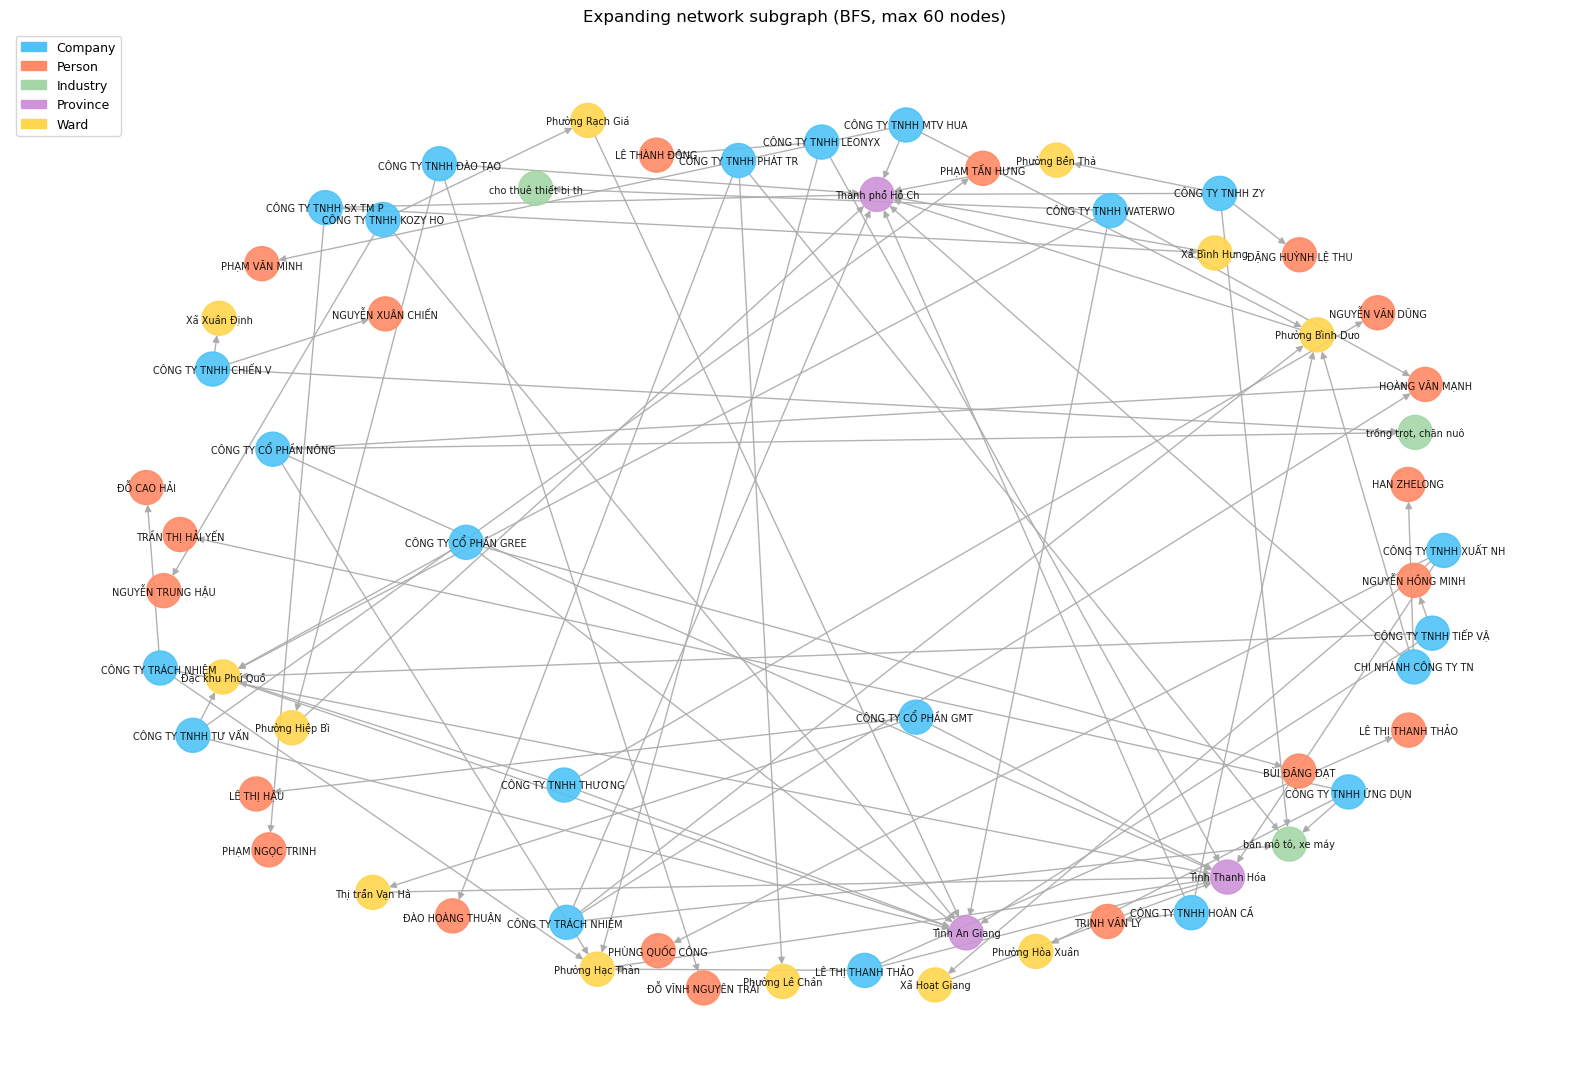

Da luu: e:\3T credit score\photo\graph_demo.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

random.seed(42)

# === Bước 1: chọn seed Person (>= 2 cty non-branch) ===
seed_person = None
for n, d in G.nodes(data=True):
    if d.get("node_type") == "Person":
        cos = [src for src, dst, ed in G.in_edges(n, data=True)
               if ed.get("edge_type") == "DAI_DIEN"]
        non_br = [c for c in cos if G.nodes[c].get("is_branch") == "False"]
        if len(non_br) >= 2:
            seed_person = n
            break

# === Bước 2: BFS expand với sample limit mỗi loại hub ===
SAMPLE_LIMIT = {
    "Province": 2,
    "Ward":     3,
    "Industry": 3,
    "Person":   10,
}
MAX_NODES = 60

subgraph_nodes = {seed_person}

# Hop 1: seed Person → các Company đại diện
companies_h1 = [src for src, dst, ed in G.in_edges(seed_person, data=True)
                if ed.get("edge_type") == "DAI_DIEN"]
for c in companies_h1:
    subgraph_nodes.add(c)

# Hop 2: mỗi Company → Industry, Ward, Province
hubs_to_expand = set()
for c in companies_h1:
    for nb in G.successors(c):
        subgraph_nodes.add(nb)
        nb_type = G.nodes[nb].get("node_type")
        if nb_type in ("Industry", "Ward", "Province"):
            hubs_to_expand.add(nb)

# Hop 3: mỗi hub → sample Company khác chưa có trong subgraph
companies_h3 = set()
for hub in hubs_to_expand:
    if len(subgraph_nodes) >= MAX_NODES:
        break
    hub_type = G.nodes[hub].get("node_type")
    limit = SAMPLE_LIMIT.get(hub_type, 2)
    in_companies = [src for src, dst, ed in G.in_edges(hub, data=True)
                    if G.nodes[src].get("node_type") == "Company"
                    and src not in subgraph_nodes]
    sampled = random.sample(in_companies, min(limit, len(in_companies)))
    for c in sampled:
        subgraph_nodes.add(c)
        companies_h3.add(c)

# Hop 4: các Company mới → Person đại diện + Ward của chúng
for c in companies_h3:
    if len(subgraph_nodes) >= MAX_NODES:
        break
    for nb in G.successors(c):
        nb_type = G.nodes[nb].get("node_type")
        if nb_type in ("Person", "Ward"):
            subgraph_nodes.add(nb)

# Cap final: ưu tiên giữ seed + companies_h1 + hubs
if len(subgraph_nodes) > MAX_NODES:
    must_keep = {seed_person} | set(companies_h1) | hubs_to_expand
    others = list(subgraph_nodes - must_keep)
    subgraph_nodes = must_keep | set(others[:MAX_NODES - len(must_keep)])

SG = G.subgraph(subgraph_nodes).copy()

from collections import Counter as _Counter
type_count = _Counter(d.get("node_type") for _, d in SG.nodes(data=True))
print(f"Subgraph: {SG.number_of_nodes()} nodes, {SG.number_of_edges()} edges")
print(f"Breakdown: {dict(type_count)}")
print(f"Seed person: {seed_person}")

# === Vẽ bằng pyvis ===
COLOR_MAP = {
    "Company":  "#4FC3F7",
    "Person":   "#FF8A65",
    "Industry": "#A5D6A7",
    "Province": "#CE93D8",
    "Ward":     "#FFD54F",
}

try:
    from pyvis.network import Network

    net = Network(height="620px", width="100%", directed=True,
                  notebook=False, cdn_resources="remote",
                  bgcolor="#1a1a2e", font_color="white")
    net.toggle_physics(True)

    for node_id, data in SG.nodes(data=True):
        nt = data.get("node_type", "Unknown")
        label = data.get("name", node_id)
        if len(label) > 35:
            label = label[:33] + ".."
        net.add_node(node_id, label=label,
                     color=COLOR_MAP.get(nt, "#999"),
                     title=f"[{nt}] {data.get('name', '')}")

    for src, dst, data in SG.edges(data=True):
        et = data.get("edge_type", "")
        net.add_edge(src, dst, title=et, label=et, arrows="to")

    html_path = "../photo/graph_demo.html"
    net.save_graph(html_path)
    print(f"Da luu: {html_path}")

except ImportError:
    print("pyvis chua cai -> dung matplotlib")
    node_colors = [COLOR_MAP.get(SG.nodes[n].get("node_type", ""), "#999") for n in SG.nodes()]
    labels = {n: (SG.nodes[n].get("name", n)[:20] if SG.nodes[n].get("name") else n.split("::")[-1][:20])
              for n in SG.nodes()}
    fig, ax = plt.subplots(figsize=(16, 11))
    pos = nx.spring_layout(SG, seed=42, k=1.8)
    nx.draw_networkx(SG, pos=pos, ax=ax,
                     node_color=node_colors, node_size=600,
                     labels=labels, font_size=7,
                     arrows=True, edge_color="#aaa", alpha=0.9)
    patches = [mpatches.Patch(color=c, label=nt) for nt, c in COLOR_MAP.items()]
    ax.legend(handles=patches, loc="upper left", fontsize=9)
    ax.set_title("Expanding network subgraph (BFS, max 60 nodes)")
    ax.axis("off")
    plt.tight_layout()
    img_path = "../photo/graph_demo.png"
    plt.savefig(img_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu: {img_path}")

## 7. Export graph

Lưu graph ra 3 định dạng: GraphML, nodes CSV, edges CSV.

**Kết quả:**
- `company_graph.graphml` — **1,161.6 KB** (~1.1 MB): giảm ~78% so với bản cũ 5,128 KB — chủ yếu nhờ bỏ 20,000+ cạnh ngành phụ
- `nodes.csv` — **277.4 KB**: 2,661 dòng
- `edges.csv` — **312.2 KB**: 4,369 dòng, gọn hơn nhiều so với bản cũ 2,498 KB

Lưu ý: khi export GraphML, cần convert `bool` → `str` vì thư viện xml không xử lý được Python bool trực tiếp.

In [7]:
output_dir = "../data"

# --- GraphML ---
graphml_path = os.path.join(output_dir, "company_graph.graphml")
# Chuyen bool -> string cho tuong thich graphml
G_export = G.copy()
for nid in G_export.nodes():
    for k, v in G_export.nodes[nid].items():
        if isinstance(v, bool):
            G_export.nodes[nid][k] = str(v)
for u, v, k in G_export.edges(keys=True):
    for attr, val in G_export.edges[u, v, k].items():
        if isinstance(val, bool):
            G_export.edges[u, v, k][attr] = str(val)
nx.write_graphml(G_export, graphml_path)
print(f"Da luu GraphML : {graphml_path}")

# --- Nodes CSV ---
nodes_data = []
for node_id, data in G.nodes(data=True):
    row = {"id": node_id, "node_type": data.get("node_type", ""), "name": data.get("name", "")}
    row.update({k: v for k, v in data.items() if k not in ("node_type", "name")})
    nodes_data.append(row)
nodes_df = pd.DataFrame(nodes_data)
nodes_csv = os.path.join(output_dir, "nodes.csv")
nodes_df.to_csv(nodes_csv, index=False, encoding="utf-8-sig")
print(f"Da luu nodes   : {nodes_csv}  ({len(nodes_df):,} nodes)")

# --- Edges CSV ---
edges_data = []
for src, dst, data in G.edges(data=True):
    row = {"source": src, "target": dst, "edge_type": data.get("edge_type", "")}
    row.update({k: v for k, v in data.items() if k != "edge_type"})
    edges_data.append(row)
edges_df = pd.DataFrame(edges_data)
edges_csv = os.path.join(output_dir, "edges.csv")
edges_df.to_csv(edges_csv, index=False, encoding="utf-8-sig")
print(f"Da luu edges   : {edges_csv}  ({len(edges_df):,} edges)")

print(f"\nTom tat file xuat ra:")
for f in ["company_graph.graphml", "nodes.csv", "edges.csv"]:
    fpath = os.path.join(output_dir, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:<30}: {size_kb:.1f} KB")

Da luu GraphML : e:\3T credit score\data\company_graph.graphml
Da luu nodes   : e:\3T credit score\data\nodes.csv  (2,661 nodes)
Da luu edges   : e:\3T credit score\data\edges.csv  (4,369 edges)

Tom tat file xuat ra:
  company_graph.graphml         : 1158.9 KB
  nodes.csv                     : 274.7 KB
  edges.csv                     : 312.2 KB


## 8. Kết luận

**Graph đã build được gì:**
- Heterogeneous graph với **2,661 nodes** (5 loại) và **4,369 edges** (5 loại)
- Node Company có property đầy đủ: tax_code, is_branch, status, company_age_days, province, ward
- Mỗi công ty có tối đa 1 cạnh LINH_VUC → graph gọn, không bị nhiễu bởi ngành phụ
- Graph export ra 3 format: GraphML (~1.2 MB), nodes.csv (275 KB), edges.csv (312 KB)

**Tiền xử lý đã làm trước khi build:**
- Normalize province names (Section 3 cell mới): chuẩn hóa các biến thể viết hoa/viết thường/abbreviation của TP.HCM, Hà Nội, Đà Nẵng, Hải Phòng, Cần Thơ. Sau khi chạy, số province unique vẫn = 33 (data gốc thực ra đã clean về cách viết tỉnh), nhưng cell vẫn giữ lại như defensive measure cho các dataset tương lai.

**Phát hiện về THUOC_PROVINCE (= 507 > Ward = 489):**
- Ban đầu nghĩ là do tên tỉnh viết khác nhau → đã thử normalize nhưng không thay đổi.
- Sau khi điều tra: **17 ward bị map sang ≥2 province** là vì tên phường/xã **trùng nhau giữa các tỉnh khác nhau** (data reality của Việt Nam), không phải lỗi nhập liệu.
- Vd: "Phường An Hải" có ở Đà Nẵng và Hải Phòng; "Xã Bình Minh" có ở 3 tỉnh.
- Fix triệt để (nếu cần): đổi Ward ID thành `WARD::<tên>::<tỉnh>` để 2 phường vật lý khác nhau thành 2 node riêng. Hiện chấp nhận thiết kế hiện tại vì chỉ ảnh hưởng 17/489 ward.

**So sánh với version đầu (dùng prof_list):**
- Nodes: 2,661 vs 2,928 (giảm 267 node — bỏ Address node + ngành phụ Industry)
- Edges: 4,369 vs 24,675 (giảm 82.3%) — bỏ 20,287 cạnh ngành phụ
- Industry node: 169 vs 430 (chỉ còn ngành chính, phân bố thực chất hơn)

**Insight từ kết quả:**
- Vẫn chỉ 1 connected component — Province/Ward là hub địa lý nối tất cả công ty cùng tỉnh/phường. Khi tính embedding cần lọc bớt loại cạnh này (như đã làm trong model.ipynb).
- Top lĩnh vực chính phân bố đều: xây dựng nhà ở (43), bán buôn (40), F&B (20). Không có ngành nào chiếm >5% tổng.
- HOÀNG VĂN MẠNH đại diện 3 pháp nhân độc lập (0 chi nhánh) — đáng theo dõi nhất.

**Hạn chế còn lại:**
- Province/Ward tạo kết nối giả — vấn đề structural khi nhúng (đã workaround trong model.ipynb)
- Thiếu dữ liệu tài chính (doanh thu, lợi nhuận, nợ)
